# Constant birth term - Inference Quality Analyses

In this notebook we use synthetic viral read count data from a fully-parameterised toy population to theoretically assess
 - (1) the practical identifiability and 
 - (2) the quality of parameter inference

when the rodent population are assumed to follow the dynamics of the SIR algorithm with contant birth term rate. If the estimates of the population model parameters are close to the true model parameter values that produced the toy population in the first place imply the validity of inferential approach, and therefore lend credibility when the same pipeline is used with real metaviromic data, as done in _James Hay et al. (2021)[1]_.

Similar to field studies, random samples of rodents are drawn from the simulated toy population at predifined sampling times, which satisfy the following:
 - same total number of rodents sampled at each time point;
 - the sampled individuals can be either susceptible (S), infected (I) or recovered (R), with no predefined quantities of each;
 - all individuals sampled are born and alive at the time of sampling.

For each of the sampled individuals, we use the SIR model's embedded `viral_read_model` to produce viral read count data, similar to what data is produced from the field studies (byproduct in our analyses, ground truth in real studies).

Two parameter inference approaches are evaluated:
 - (1) an optimisation approach, using the CMA-ES method from *Pints [2]*, and 
 - (2) a sampling approach, using the HaarioBardenetACMC method from *Pints [2]*.

We replicate these analyses for a range of sample sizes and frequencies of sampling values, to compare the quality of parameter estimation and proportion of infected population across different sampling protocols.

**************
### References
[1] James A. Hay et al., _Estimating epidemiologic dynamics from cross-sectional viral load distributions_. Science373,**eabh0635(2021)**. DOI:10.1126/science.abh0635

[2] Clerx, M., Robinson, M., Lambert, B., Lei, C. L., Ghosh, S., Mirams, G. R., & Gavaghan, D. J.,
_Probabilistic Inference on Noisy Time Series (PINTS)_.
Journal of Open Research Software (2019), 7(1), 23. DOI:10.5334/jors.252

In [1]:
# Load necessary libraries
import numpy as np
import pandas as pd
from scipy.stats import multinomial, skew, gumbel_r
import math
import metavirommodel as mm
import metavirommodel.inference as mmi
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pints
from matplotlib import pyplot as plt
import pints.plot

# Choose array of colours for graphs and compartments names
colours = ['blue', 'red', 'green', 'purple', 'orange', 'black', 'gray', 'pink']
compartments = ['S', 'I', 'R']

# Set random seed
np.random.seed(9)

## Gillespie stochastic SIR algorithm with contant birth term rate

#### Define rodent population

In [2]:
# Set initial reproduction number
R_0 = 3

# Set initial population state S - I - R
N_init = 400
# S_init = int(N_init / R_0)
S_init = 380
I_init = N_init - S_init
R_init = 0
initial_population = [S_init, I_init, R_init]

# Set birth rate
theta = 0.05

# Set death rates
mu = 0.002
nu = 0

# Set transition rates
infect_period = 15
beta =  R_0 / infect_period
gamma = 1 / infect_period

# Coalesce into paramater vector
parameters = initial_population
parameters.extend([theta, mu, nu, beta, gamma])

# Instantiate algorithm
algorithm = mm.Metaviromodel()

# Select start and end times
start_time = 1
end_time = 360

times = list(range(start_time, end_time+1))

# Select number of experiments
num_experiments = 1

output_algorithm = []

S_history_algorithm = []
I_history_algorithm = []
R_history_algorithm = []

I_times_history_algorithm = []
R_times_history_algorithm = []

for _ in range(num_experiments):
    output, S_history, I_history, R_history, I_times_history, R_times_history = algorithm.simulate_fixed_times(parameters, start_time, end_time)
    output_algorithm.append(output)

    S_history_algorithm.append(S_history)
    I_history_algorithm.append(I_history)
    R_history_algorithm.append(R_history)

    I_times_history_algorithm.append(I_times_history)
    R_times_history_algorithm.append(R_times_history)

output_algorithm = np.asarray(output_algorithm)

### Plot output of Gillespie for the different compartments

In [3]:
# Trace names - represent the type of individuals for the simulation
trace_name = ['{}'.format(s) for s in compartments]

# Names of panels
panels = ['{} only'.format(s) for s in compartments] + ['Total Population']

fig = go.Figure()
fig = make_subplots(rows=int(np.ceil(len(panels)/2)), cols=2, subplot_titles=tuple('{}'.format(p) for p in panels))

# Add traces to the separate counts panels
for s, spec in enumerate(compartments):
    fig.add_trace(
        go.Scatter(
            y=np.mean(output_algorithm[:, :, s], axis=0).tolist(),
            x=times,
            mode='lines',
            name=trace_name[s],
            line_color=colours[s]
        ),
        row= int(np.floor(s / 2)) + 1,
        col= s % 2 + 1
    )

fig.add_trace(
    go.Scatter(
        y=np.mean(np.sum(output_algorithm, axis=2), axis=0).tolist(),
        x=times,
        mode='lines',
        name='Total Population',
        line_color='black'
    ),
    row= 2,
    col= 2
)

# Add axis labels
fig.update_layout(
    title='Counts of compartments over time:<br>IC = {}, θ = {}, μ = {}, v = {}, β = {:.2f}, γ = {:.2f}'.format(parameters[0:3], parameters[3], parameters[4], parameters[5], parameters[6], parameters[7]),
    width=1100, 
    height=600,
    plot_bgcolor='white',
    xaxis=dict(
        linecolor='black',
        title = 'Time (days)'
        ),
    yaxis=dict(
        linecolor='black',
        title = 'Individuals'),
    xaxis2=dict(
        linecolor='black',
        title = 'Time (days)'
        ),
    yaxis2=dict(
        linecolor='black',
        title = 'Individuals'),
    xaxis3=dict(
        linecolor='black',
        title = 'Time (days)'
        ),
    yaxis3=dict(
        linecolor='black',
        title = 'Individuals'),
    xaxis4=dict(
        linecolor='black',
        title = 'Time (days)'
        ),
    yaxis4=dict(
        linecolor='black',
        title = 'Individuals')
    #legend=dict(
    #    orientation="h",
    #    yanchor="bottom",
    #    y=1.02,
    #    xanchor="right",
    #    x=1
    #)
    )

fig.write_image('images/SIR-gillespie.pdf')
fig.show()

## Produce Viral read counts values

In [4]:
# Set parameter for the viral read counts model
t_eclipse = 3  # (0 days) Time from infection to initial viral growth
t_peak = 7  # (5 days ) Time from initial viral growth to peak viral load
t_switch = 5  # (9.38 days) Time from peak viral load to secondary waning phase
t_mod = 15  # (14 days) time from secondary waning phase until gumbel distribution reaches its min scale parameter
t_LOD = math.inf # ( inf days ) Time from infection until modal read counts value is equal to the limit of detection

sigma_obs = 0.25  # Initial scale parameter for the Gumbel distribution until a=teclipse+tpeak+tswitch
s_mod = 0.4  # 0.4 multiplicative factor applied to scale paramter for the Gumble distrbution - starting at t_eclipse + t_peak + t_switch + t_scle
v_zero = 2  # read counts value at time of infection
v_peak = 3880  # (20) Modal read counts value at peak viral load
v_switch = 480  # (33) Modal read counts value at a = teclipse + tpeak + tswitch
v_LOD = 2  # Limit of detection of read counts value

parameters_vl = [
    t_eclipse, t_peak, t_switch, t_mod, t_LOD,
    v_zero, v_peak, v_switch, v_LOD,
    s_mod, sigma_obs]

# Set read counts value for the suceptible and recovered individuals
VR_susc = 0

### Plot Viral read Model

In [5]:
time_from_infec = np.arange(1, 50)
vr_val = []

for ti in time_from_infec:
    ti_vr_val = []
    for _ in range(10000):
        ti_vr_val.append(algorithm.viral_read_model(parameters_vl, ti))
    vr_val.append(ti_vr_val)

vr_val = np.asarray(vr_val)

In [6]:
fig = go.Figure()

fig.add_trace(
    go.Scatter(
        y=time_from_infec,
        x=np.mean(vr_val, axis=1),
        mode='lines',
        name='Mean Viral read',
        showlegend=False,
    )
)

fig.add_trace(
    go.Scatter(
        y=time_from_infec.tolist() + time_from_infec.tolist()[::-1],
        x=np.quantile(vr_val, 0.975, axis=1).tolist() + np.quantile(vr_val, 0.025, axis=1).tolist()[::-1],
        mode='lines',
        fill='toself',
        fillcolor='blue',
        line_color='blue',
        opacity=0.3,
        showlegend=False,
    )
)

# Add axis labels
fig.update_layout(
    width=500, 
    height=500,
    plot_bgcolor='white',
    xaxis=dict(
        linecolor='black',
        title = 'Mean Viral read',
        autorange='reversed'
        ),
    yaxis=dict(
        linecolor='black',
        title = 'Time since infection'),
    #legend=dict(
    #    orientation="h",
    #    yanchor="bottom",
    #    y=1.02,
    #    xanchor="right",
    #    x=1
    #)
    )

fig.write_image('images/SIR_Viral_read_model.pdf')
fig.show()

### Compute the history of recovered individuals that fully clear the virus and generation times distribution

#### 0 = 'not cleared'; 1 = 'cleared'

In [7]:
# Daily probability of recovered fully clearing the virus
p_addl = 0.2

R_history_clear_algorithm = []

# Go through each run experiment
for _ in range(num_experiments):
    R_history_clear = []

    # Go through each recorded day
    for t, time in enumerate(times):
        current_clear_status = []

        # If there are any recovered individual
        if len(R_times_history_algorithm[_][t]) > 0:
            # Go through each of them and
            for ind, ind_ID in enumerate(R_history_algorithm[_][t]):
                clear_status = 0

                # If they have previously cleared the virus they signal that
                if ind_ID in R_history_algorithm[_][t-1] and R_history_clear[-1][R_history_algorithm[_][t-1].index(ind_ID)] == 1:
                    clear_status = 1
                # if not, they could do it today, if their time since infection exceeds teclipse + tpeak + tswitch
                elif time > R_times_history_algorithm[_][t][ind] + t_eclipse + t_peak + t_switch:
                    clear_status = 1 - np.random.binomial(1, p = (1-p_addl)**(
                        time - R_times_history_algorithm[_][t][ind] - t_eclipse - t_peak - t_switch))

                current_clear_status.append(clear_status)

        R_history_clear.append(current_clear_status)                

    R_history_clear_algorithm.append(R_history_clear)

In [8]:
# Compute the generation times distribution, which also follows a
# right-skewed Gumbel distribution
generation_times = []

for _ in range(70):
    if _ < t_eclipse + t_peak + t_switch:
        generation_times.append(
            1-gumbel_r.cdf(
                np.log(v_LOD),
                algorithm._compute_mode_vr_model(
                    _, t_eclipse, t_peak, t_switch, t_LOD,
                    np.log(v_zero), np.log(v_peak), np.log(v_switch), np.log(v_LOD)),
                algorithm._compute_sigma_vr_model(
                    _, t_eclipse, t_peak, t_switch, t_mod,
                    s_mod, sigma_obs)
            ))
        
    else:
        generation_times.append(
            (1-gumbel_r.cdf(
                np.log(v_LOD),
                algorithm._compute_mode_vr_model(
                    _, t_eclipse, t_peak, t_switch, t_LOD,
                    np.log(v_zero), np.log(v_peak), np.log(v_switch), np.log(v_LOD)),
                algorithm._compute_sigma_vr_model(
                    _, t_eclipse, t_peak, t_switch, t_mod,
                    s_mod, sigma_obs)
            )) * (1-p_addl)**(_ - t_eclipse - t_peak - t_switch))

#### Plot generation times

In [9]:
fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=time_from_infec,
        y=generation_times,
        mode='lines',
        name='Generation times',
        showlegend=False,
    )
)

fig.show()

## Parameter inference
In this section we test the quality of parameter inference for two distinct inference approaches: 

- (1) an optimisation approach, using the CMA-ES method from *Pints [2]*, and 
 - (2) a sampling approach, using the HaarioBardenetACMC method from *Pints [2]*,

for a range of sample sizes and frequencies of sampling values, to compare the quality of parameter estimation and proportion of infected population across different sampling protocols.

#### Sample individuals with specific frequencies and in specific batch sizes

In [10]:
freq_samplying_range = [3, 5, 7, 15, 21, 30]
sample_size_range = [20, 30, 40, 50]

### 1. Optimisation method

#### Method to create Ct value data and ground truth

In [11]:
def sensitivity_analysis_run(sample_points, sample_size):
    vr_values = []
    vr_infec = []

    vr_susc_ids = []
    vr_infec_ids = []
    vr_recov_ids = []

    vr_time_of_recov_infec = []
    vr_time_of_infec = []
    vr_time_since_infec = []

    for _ in range(num_experiments):
        experiment_vr_values = []
        experiment_infec = []

        experiment_susc_ids = []
        experiment_infec_ids = []
        experiment_recov_ids = []

        experiment_time_of_recov_infec = []
        experiment_time_of_infec = []
        experiment_time_since_infec = []
        # At each point in time sample sample_size individuals
        for time in sample_points:
            # Identify the current infections at the specified timepoint
            current_susceptibles = S_history_algorithm[_][time-1]
            current_infections = I_history_algorithm[_][time-1]
            current_recovered = R_history_algorithm[_][time-1]
            current_infection_times = I_times_history_algorithm[_][time-1]
            current_recov_infection_times = R_times_history_algorithm[_][time-1]
            current_recov_clear_virus_status = R_history_clear_algorithm[_][time-1]
            current_recov_clear_virus_status = R_history_clear_algorithm[_][time-1]

            # Sample without replacement the sample_size individuals and
            # determine their time since infection to produce Ct values
            number_selected_susc, number_selected_infec, number_selected_rec = \
                multinomial.rvs(
                    n=sample_size,
                    p=output_algorithm[_, time-1, :]/np.sum(output_algorithm[_, time-1, :])) # determine how many of those sampled are S, I and R

            # First add the Ct values for the sampled susceptibele and recovered individuals
            sampled_vr_values = [VR_susc] * number_selected_susc

            selected_individuals_susc_ids = np.random.choice(
                    current_susceptibles,
                    size=number_selected_susc,
                    replace=False).tolist() # determine the ids of those sampled Ss
            
            if len(current_recov_infection_times) > 0:
                # If we have at least one selected recovered
                selected_individuals_indices = np.random.choice(
                    range(len(current_recov_infection_times)),
                    size=number_selected_rec,
                    replace=False).tolist() # determine the indices of those sampled Rs
            
                selected_individuals_rec_ids = [current_recovered[_] for _ in selected_individuals_indices]

                # Determine the time of infection of those sampled Rs
                selected_individuals_recov_infec_times = [current_recov_infection_times[_] for _ in selected_individuals_indices]

                sample_time_since_infec = time - selected_individuals_recov_infec_times # determine how long since infection for selected Rs

                # Determine the clearence of infection of those sampled Rs
                selected_individuals_clear_virus_status = [current_recov_clear_virus_status[_] for _ in selected_individuals_indices]

                # Run viral read model to determine individual viral read counts for each sample
                for i, ti in enumerate(sample_time_since_infec):
                    sampled_vr_values.append(algorithm.viral_read_model(parameters_vl, ti) * selected_individuals_clear_virus_status[i])

            elif number_selected_rec > 0:
                # If initial step when no history of infection is provided
                for i in range(number_selected_rec):
                    sampled_vr_values.append(algorithm.viral_read_model(parameters_vl, time))
                
                sample_time_since_infec = np.zeros(number_selected_rec)
                selected_individuals_rec_ids = [] 
            else:
                sample_time_since_infec = []
                selected_individuals_rec_ids = []

            if len(current_infection_times) > 0:
                # If we have at least one selected infection
                selected_individuals_indices = np.random.choice(
                    range(len(current_infection_times)),
                    size=number_selected_infec,
                    replace=False).tolist() # determine the indices of those sampled Is
                
                # Determine the ids of those sampled Is
                selected_individuals_infec_ids = [current_infections[_] for _ in selected_individuals_indices]

                # Determine the time of infection of those sampled Is
                selected_individuals_infec_times = [current_infection_times[_] for _ in selected_individuals_indices]
            
                sample_time_since_infec = time - selected_individuals_infec_times # determine how long since infection for selected Is

                # Run Ct model to determine individual Ct counts for each sample
                for ti in sample_time_since_infec:
                    sampled_vr_values.append(algorithm.viral_read_model(parameters_vl, ti))
            
            elif number_selected_infec > 0:
                # If initial step when no history of infection is provided
                for i in range(number_selected_infec):
                    sampled_vr_values.append(algorithm.viral_read_model(parameters_vl, time))
                
                selected_individuals_infec_times = np.zeros(number_selected_infec)
                sample_time_since_infec = np.zeros(number_selected_infec)
                selected_individuals_infec_ids = [] 
            else:
                selected_individuals_infec_times = []
                sample_time_since_infec = []
                selected_individuals_infec_ids = [] 

            experiment_vr_values.append(sampled_vr_values)
            experiment_infec.append(number_selected_infec)
            
            experiment_susc_ids.append(selected_individuals_susc_ids)
            experiment_infec_ids.append(selected_individuals_infec_ids)
            experiment_recov_ids.append(selected_individuals_rec_ids)

            experiment_time_of_recov_infec.append(selected_individuals_recov_infec_times)
            experiment_time_of_infec.append(selected_individuals_infec_times)
            experiment_time_since_infec.append(sample_time_since_infec)
        
        vr_values.append(experiment_vr_values)
        vr_infec.append(experiment_infec)

        vr_susc_ids.append(experiment_susc_ids)
        vr_infec_ids.append(experiment_infec_ids)
        vr_recov_ids.append(experiment_recov_ids)

        vr_time_of_recov_infec.append(experiment_time_of_recov_infec)
        vr_time_of_infec.append(experiment_time_of_infec)
        vr_time_since_infec.append(experiment_time_since_infec)

    vr_values = np.asarray(vr_values)
    vr_infec = np.asarray(vr_infec)

    vr_time_of_infec_data = []

    for _ in range(num_experiments):
        experiment_vr_time_of_infec_data = pd.DataFrame(columns=['ID', 'Value'])
        for t, time in enumerate(sample_points):
            experiment_vr_time_of_infec_data = pd.concat(
                [
                    experiment_vr_time_of_infec_data,
                    pd.DataFrame({
                        'ID': vr_susc_ids[_][t] + vr_recov_ids[_][t] + vr_infec_ids[_][t],
                        'Value': [400] * len(vr_susc_ids[_][t]) + vr_time_of_recov_infec[_][t] + vr_time_of_infec[_][t]
                    })
                ])
            
        vr_time_of_infec_data.append(experiment_vr_time_of_infec_data)

    vr_values_data = []

    for _ in range(num_experiments):
        experiment_vr_values_data = pd.DataFrame(columns=['ID', 'TimeOfSample', 'Value'])
        for t, time in enumerate(sample_points):
            experiment_vr_values_data = pd.concat(
                [
                    experiment_vr_values_data,
                    pd.DataFrame({
                        'ID': vr_susc_ids[_][t] + vr_recov_ids[_][t] + vr_infec_ids[_][t],
                        'TimeOfSample': [time] * sample_size,
                        'Value': vr_values[_, t, :].tolist()
                    })
                ])
            
        vr_values_data.append(experiment_vr_values_data)

    mvr_inference = mmi.MVRVirReadInfer(algorithm, generation_times=generation_times)

    # Read Vireal read counts and Ct values data
    mvr_inference.read_viral_read_data(vr_values_data[0], parameters_vl)

    R0_found = mvr_inference.optimisation_problem_setup()[0]

    shody_recov_freq = []

    for t in range(vr_values[0].shape[0]):
        shody_recov_freq.append((np.where((vr_values[0][t, :] > 130) & (vr_values[0][t, :] < 150))[0]).shape[0] /sample_size)

    return vr_values_data, R0_found, shody_recov_freq, vr_infec[0, :] / sample_size

In [12]:
# Transform birth rate and death rate of infected into function format for inference method
parameters[3] = lambda _: theta
parameters[5] = lambda _: nu

#### Method to run inference with Viral read count data and plot inferred trajectories against ground truth

In [13]:
def routine_run(freq_samplying, sample_size):
    sample_points = np.arange(20, 100, freq_samplying)

    # For each choice of sample size and frequency infer parameters: 
    vr_values_data, R0_found, shody_recov_freq, infec_freq_sample = sensitivity_analysis_run(sample_points, sample_size)

    mvr_inference = mmi.MVRVirReadInfer(algorithm, generation_times=generation_times)
    mvr_inference.read_viral_read_data(vr_values_data[0], parameters_vl)
    mvr_inference._create_posterior()

    parameters[4] = R0_found[1]
    parameters[6] = R0_found[0] / infect_period

    theta_found = []
    infec_found = []
    for _ in range(1000):
        output_found = algorithm.simulate_fixed_times(parameters, start_time, end_time)[0]

        theta_found.append(np.divide(output_found[:, 1], np.sum(output_found, axis=1)))
        infec_found.append(output_found[:, 1])

    theta_found = np.array(theta_found)
    infec_found = np.array(infec_found)

    theta_found_mean = np.mean(theta_found, axis=0)
    theta_found_upper = np.quantile(theta_found, 0.975, axis=0)
    theta_found_lower = np.quantile(theta_found, 0.025, axis=0)

    infec_found_mean = np.mean(infec_found, axis=0)
    infec_found_upper = np.quantile(infec_found, 0.975, axis=0)
    infec_found_lower = np.quantile(infec_found, 0.025, axis=0)

    output_found_det = mvr_inference.loglikelihood._run_sir_model(
        parameters, np.arange(max(mvr_inference.loglikelihood._vr_sampled_times))
    )
    theta_found_det = np.divide(output_found_det[:, 1], np.sum(output_found_det, axis=1))
    infec_found_det = output_found_det[:, 1]

    fig = go.Figure()

    fig.add_trace(
        go.Scatter(
            y=(output_algorithm[0, :, 1] / np.mean(np.sum(output_algorithm, axis=2), axis=0)).tolist(),
            x=times,
            mode='lines',
            name='True freq',
            line_color='red'
        )
    )

    fig.add_trace(
        go.Scatter(
            y=infec_freq_sample.tolist(),
            x=sample_points,
            mode='lines',
            name='Sample freq',
            line_color='blue'
        )
    )

    fig.add_trace(
        go.Scatter(
            y=(1 - np.array(shody_recov_freq)).tolist(),
            x=sample_points,
            mode='lines',
            name='Sample freq (extreme I)',
            line_color='green'
        )
    )

    fig.add_trace(
        go.Scatter(
            y=theta_found_det.tolist(),
            x=times,
            mode='lines',
            name='Inferred freq - det',
            line_color='black',
            line_dash='dash'
        )
    )

    fig.add_trace(
        go.Scatter(
            y=theta_found_mean.tolist(),
            x=times,
            mode='lines',
            name='Inferred freq',
            line_color='black'
        )
    )

    fig.add_trace(
        go.Scatter(
            x=times + times[::-1],
            y=theta_found_upper.tolist() + theta_found_lower.tolist()[::-1],
            fill='toself',
            fillcolor='black',
            line_color='black',
            opacity=0.3,
            mode='lines',
            showlegend=False,
            name='Inferred freq'
        )
    )

    # Add axis labels
    fig.update_layout(
        title='Sensitivity analysis: Frequency:{} days; Sample size:{}'.format(freq_samplying, sample_size),
        width=700, 
        height=400,
        plot_bgcolor='white',
        xaxis=dict(
            linecolor='black',
            title = 'Time (days)'
            ),
        yaxis=dict(
            linecolor='black',
            title = 'Individuals'),
        )

    fig.write_image('images/SIR_Viral_read_CredInt_Freq_{}_Sample_size_{}.pdf'.format(freq_samplying, sample_size))
    fig.show()

    fig = go.Figure()

    fig.add_trace(
        go.Scatter(
            y=(output_algorithm[0, :, 1]).tolist(),
            x=times,
            mode='lines',
            name='True freq',
            line_color='red'
        )
    )

    fig.add_trace(
        go.Scatter(
            y=infec_found_det.tolist(),
            x=times,
            mode='lines',
            name='Inferred freq - det',
            line_color='black',
            line_dash='dash'
        )
    )

    fig.add_trace(
        go.Scatter(
            y=infec_found_mean.tolist(),
            x=times,
            mode='lines',
            name='Inferred freq',
            line_color='black'
        )
    )

    fig.add_trace(
        go.Scatter(
            x=times + times[::-1],
            y=infec_found_upper.tolist() + infec_found_lower.tolist()[::-1],
            fill='toself',
            fillcolor='black',
            line_color='black',
            opacity=0.3,
            mode='lines',
            showlegend=False,
            name='Inferred freq'
        )
    )

    # Add axis labels
    fig.update_layout(
        title='Total Infections: Frequency:{} days; Sample size:{}'.format(freq_samplying, sample_size),
        width=700, 
        height=400,
        plot_bgcolor='white',
        xaxis=dict(
            linecolor='black',
            title = 'Time (days)'
            ),
        yaxis=dict(
            linecolor='black',
            title = 'Individuals'))

    fig.write_image('images/Total_Infec_SIR_Viral_read__Freq_{}_Sample_size_{}.pdf'.format(freq_samplying, sample_size))
    fig.show()

#### Run optimisation-based inference method for multiple sampling protcols

In [14]:
routine_run(freq_samplying_range[2], sample_size_range[0])

/var/folders/ph/jyxnc9y52svgq2k5lt2q4r000000gp/T/ipykernel_69974/3964525704.py:144: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.

/var/folders/ph/jyxnc9y52svgq2k5lt2q4r000000gp/T/ipykernel_69974/3964525704.py:160: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.

/Users/ioaros/opt/anaconda3/envs/metavirom/lib/python3.13/site-packages/pints/_optimisers/__init__.py:988: UserWarning:

The method `set_max_unchanged_iterations` is deprecated. Please use `set_function_tolerance` instead.



Maximising LogPDF
Using Covariance Matrix Adaptation Evolution Strategy (CMA-ES)
Running in sequential mode.
Population size: 6
Iter. Eval. Best      Current   Time    
0     6     -669.4867 -669.4867   0:06.3
1     12    -666.5777 -666.5777   0:11.9
2     18    -665.4943 -665.4943   0:16.9
3     24    -664.585  -664.585    0:21.9
20    126   -663.0327 -663.033    1:29.3
40    246   -555.1054 -556.5689   2:59.1
60    366   -553.9617 -554.4418   4:33.8
80    486   -553.9248 -554.0192   6:00.2
100   606   -553.9122 -553.9122   7:26.1
120   726   -553.9113 -553.9113   8:52.4
140   846   -553.9112 -553.9112  10:29.3
156   936   -553.9111 -553.9111  11:31.8
Halting: No significant change in best function evaluation for 100 iterations.
[1.96702608e+00 1.00000232e-03] -553.9111448268242
Optimisation phase is finished.


In [15]:
routine_run(freq_samplying_range[2], sample_size_range[3])

/var/folders/ph/jyxnc9y52svgq2k5lt2q4r000000gp/T/ipykernel_69974/3964525704.py:144: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.

/var/folders/ph/jyxnc9y52svgq2k5lt2q4r000000gp/T/ipykernel_69974/3964525704.py:160: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.

/Users/ioaros/opt/anaconda3/envs/metavirom/lib/python3.13/site-packages/pints/_optimisers/__init__.py:988: UserWarning:

The method `set_max_unchanged_iterations` is deprecated. Please use `set_function_tolerance` instead.



Maximising LogPDF
Using Covariance Matrix Adaptation Evolution Strategy (CMA-ES)
Running in sequential mode.
Population size: 6
Iter. Eval. Best      Current   Time    
0     6     -1576.557 -1576.557   0:15.3
1     12    -1576.557 -1578.667   0:28.9
2     18    -1576.557 -1582.351   0:42.5
3     24    -1576.557 -1582.086   0:51.5
20    126   -1573.075 -1573.179   4:06.1
40    246   -1315.147 -1315.147   8:52.1
60    366   -1312.245 -1312.246  14:15.0
80    486   -1312.244 -1312.244  22:00.9
100   606   -1312.244 -1312.244  30:20.6
120   726   -1312.244 -1312.244  38:34.9
140   846   -1312.244 -1312.244  46:52.0
147   882   -1312.244 -1312.244  49:19.4
Halting: No significant change in best function evaluation for 100 iterations.
[1.89460057 0.00576406] -1312.2444777497058
Optimisation phase is finished.


In [16]:
routine_run(freq_samplying_range[5], sample_size_range[0])

/var/folders/ph/jyxnc9y52svgq2k5lt2q4r000000gp/T/ipykernel_69974/3964525704.py:144: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.

/var/folders/ph/jyxnc9y52svgq2k5lt2q4r000000gp/T/ipykernel_69974/3964525704.py:160: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.

/Users/ioaros/opt/anaconda3/envs/metavirom/lib/python3.13/site-packages/pints/_optimisers/__init__.py:988: UserWarning:

The method `set_max_unchanged_iterations` is deprecated. Please use `set_function_tolerance` instead.



Maximising LogPDF
Using Covariance Matrix Adaptation Evolution Strategy (CMA-ES)
Running in sequential mode.
Population size: 6
Iter. Eval. Best      Current   Time    
0     6     -133.5538 -133.5538   0:02.4
1     12    -132.7567 -132.7567   0:04.7
2     18    -132.407  -132.407    0:06.4
3     24    -132.2143 -132.2143   0:07.9
20    126   -132.1152 -132.1152   0:36.4
40    246   -131.5635 -131.5635   1:09.4
60    366   -111.7109 -111.7341   1:50.5
80    486   -111.252  -111.252    2:28.9
100   606   -111.2412 -111.2415   3:01.2
120   726   -111.2412 -111.2412   3:36.8
140   846   -111.2412 -111.2412   4:02.8
156   936   -111.2412 -111.2412   4:23.8
Halting: No significant change in best function evaluation for 100 iterations.
[2.01010909e+00 1.00000001e-03] -111.24120800060773
Optimisation phase is finished.


In [17]:
routine_run(freq_samplying_range[5], sample_size_range[3])

/var/folders/ph/jyxnc9y52svgq2k5lt2q4r000000gp/T/ipykernel_69974/3964525704.py:144: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.

/var/folders/ph/jyxnc9y52svgq2k5lt2q4r000000gp/T/ipykernel_69974/3964525704.py:160: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.

/Users/ioaros/opt/anaconda3/envs/metavirom/lib/python3.13/site-packages/pints/_optimisers/__init__.py:988: UserWarning:

The method `set_max_unchanged_iterations` is deprecated. Please use `set_function_tolerance` instead.



Maximising LogPDF
Using Covariance Matrix Adaptation Evolution Strategy (CMA-ES)
Running in sequential mode.
Population size: 6
Iter. Eval. Best      Current   Time    
0     6     -333.4771 -333.4771   0:05.6
1     12    -332.9797 -332.9797   0:10.8
2     18    -332.9797 -333.7024   0:15.4
3     24    -332.9797 -333.0696   0:21.0
20    126   -331.8429 -331.8992   1:36.2
40    246   -331.7345 -331.7345   2:51.4
60    366   -283.2292 -283.2292   4:13.3
80    486   -282.6351 -282.6945   5:48.1
100   606   -282.6147 -282.6153   7:20.0
120   726   -282.6144 -282.6144   8:44.5
140   846   -282.6144 -282.6144  10:09.5
160   966   -282.6144 -282.6144  11:30.4
163   978   -282.6144 -282.6144  11:41.0
Halting: No significant change in best function evaluation for 100 iterations.
[2.04591548e+00 1.00000000e-03] -282.6144092488825
Optimisation phase is finished.


### 2. Sampling method

#### Method to create Ct value data and ground truth

In [14]:
def sampling_sensitivity_analysis_run(sample_points, sample_size):
    vr_values = []
    vr_infec = []

    vr_susc_ids = []
    vr_infec_ids = []
    vr_recov_ids = []

    vr_time_of_recov_infec = []
    vr_time_of_infec = []
    vr_time_since_infec = []

    for _ in range(num_experiments):
        experiment_vr_values = []
        experiment_infec = []

        experiment_susc_ids = []
        experiment_infec_ids = []
        experiment_recov_ids = []

        experiment_time_of_recov_infec = []
        experiment_time_of_infec = []
        experiment_time_since_infec = []
        # At each point in time sample sample_size individuals
        for time in sample_points:
            # Identify the current infections at the specified timepoint
            current_susceptibles = S_history_algorithm[_][time-1]
            current_infections = I_history_algorithm[_][time-1]
            current_recovered = R_history_algorithm[_][time-1]
            current_infection_times = I_times_history_algorithm[_][time-1]
            current_recov_infection_times = R_times_history_algorithm[_][time-1]
            current_recov_clear_virus_status = R_history_clear_algorithm[_][time-1]

            # Sample without replacement the sample_size individuals and
            # determine their time since infection to produce Ct values
            number_selected_susc, number_selected_infec, number_selected_rec = \
                multinomial.rvs(
                    n=sample_size,
                    p=output_algorithm[_, time-1, :]/np.sum(output_algorithm[_, time-1, :])) # determine how many of those sampled are S, I and R

            # First add the Ct values for the sampled susceptibele and recovered individuals
            sampled_vr_values = [VR_susc] * number_selected_susc

            selected_individuals_susc_ids = np.random.choice(
                    current_susceptibles,
                    size=number_selected_susc,
                    replace=False).tolist() # determine the ids of those sampled Ss
            
            if len(current_recov_infection_times) > 0:
                # If we have at least one selected recovered
                selected_individuals_indices = np.random.choice(
                    range(len(current_recov_infection_times)),
                    size=number_selected_rec,
                    replace=False).tolist() # determine the indices of those sampled Rs
            
                selected_individuals_rec_ids = [current_recovered[_] for _ in selected_individuals_indices]

                # Determine the time of infection of those sampled Rs
                selected_individuals_recov_infec_times = [current_recov_infection_times[_] for _ in selected_individuals_indices]

                sample_time_since_infec = time - selected_individuals_recov_infec_times # determine how long since infection for selected Rs

                # Determine the clearence of infection of those sampled Rs
                selected_individuals_clear_virus_status = [current_recov_clear_virus_status[_] for _ in selected_individuals_indices]

                # Run viral read model to determine individual viral read counts for each sample
                for i, ti in enumerate(sample_time_since_infec):
                    sampled_vr_values.append(algorithm.viral_read_model(parameters_vl, ti) *(1 - selected_individuals_clear_virus_status[i]))

            elif number_selected_rec > 0:
                # If initial step when no history of infection is provided
                for i in range(number_selected_rec):
                    sampled_vr_values.append(algorithm.viral_read_model(parameters_vl, time))
                
                sample_time_since_infec = np.zeros(number_selected_rec)
                selected_individuals_rec_ids = [] 
            else:
                sample_time_since_infec = []
                selected_individuals_rec_ids = []

            if len(current_infection_times) > 0:
                # If we have at least one selected infection
                selected_individuals_indices = np.random.choice(
                    range(len(current_infection_times)),
                    size=number_selected_infec,
                    replace=False).tolist() # determine the indices of those sampled Is
                
                # Determine the ids of those sampled Is
                selected_individuals_infec_ids = [current_infections[_] for _ in selected_individuals_indices]

                # Determine the time of infection of those sampled Is
                selected_individuals_infec_times = [current_infection_times[_] for _ in selected_individuals_indices]
            
                sample_time_since_infec = time - selected_individuals_infec_times # determine how long since infection for selected Is

                # Run Ct model to determine individual Ct counts for each sample
                for ti in sample_time_since_infec:
                    sampled_vr_values.append(algorithm.viral_read_model(parameters_vl, ti))
            
            elif number_selected_infec > 0:
                # If initial step when no history of infection is provided
                for i in range(number_selected_infec):
                    sampled_vr_values.append(algorithm.viral_read_model(parameters_vl, time))
                
                selected_individuals_infec_times = np.zeros(number_selected_infec)
                sample_time_since_infec = np.zeros(number_selected_infec)
                selected_individuals_infec_ids = [] 
            else:
                selected_individuals_infec_times = []
                sample_time_since_infec = []
                selected_individuals_infec_ids = [] 

            experiment_vr_values.append(sampled_vr_values)
            experiment_infec.append(number_selected_infec)
            
            experiment_susc_ids.append(selected_individuals_susc_ids)
            experiment_infec_ids.append(selected_individuals_infec_ids)
            experiment_recov_ids.append(selected_individuals_rec_ids)

            experiment_time_of_recov_infec.append(selected_individuals_recov_infec_times)
            experiment_time_of_infec.append(selected_individuals_infec_times)
            experiment_time_since_infec.append(sample_time_since_infec)
        
        vr_values.append(experiment_vr_values)
        vr_infec.append(experiment_infec)

        vr_susc_ids.append(experiment_susc_ids)
        vr_infec_ids.append(experiment_infec_ids)
        vr_recov_ids.append(experiment_recov_ids)

        vr_time_of_recov_infec.append(experiment_time_of_recov_infec)
        vr_time_of_infec.append(experiment_time_of_infec)
        vr_time_since_infec.append(experiment_time_since_infec)

    vr_values = np.asarray(vr_values)
    vr_infec = np.asarray(vr_infec)

    vr_time_of_infec_data = []

    for _ in range(num_experiments):
        experiment_vr_time_of_infec_data = pd.DataFrame(columns=['ID', 'Value'])
        for t, time in enumerate(sample_points):
            experiment_vr_time_of_infec_data = pd.concat(
                [
                    experiment_vr_time_of_infec_data,
                    pd.DataFrame({
                        'ID': vr_susc_ids[_][t] + vr_recov_ids[_][t] + vr_infec_ids[_][t],
                        'Value': [400] * len(vr_susc_ids[_][t]) + vr_time_of_recov_infec[_][t] + vr_time_of_infec[_][t]
                    })
                ])
            
        vr_time_of_infec_data.append(experiment_vr_time_of_infec_data)

    vr_values_data = []

    for _ in range(num_experiments):
        experiment_vr_values_data = pd.DataFrame(columns=['ID', 'TimeOfSample', 'Value'])
        for t, time in enumerate(sample_points):
            experiment_vr_values_data = pd.concat(
                [
                    experiment_vr_values_data,
                    pd.DataFrame({
                        'ID': vr_susc_ids[_][t] + vr_recov_ids[_][t] + vr_infec_ids[_][t],
                        'TimeOfSample': [time] * sample_size,
                        'Value': vr_values[_, t, :].tolist()
                    })
                ])
            
        vr_values_data.append(experiment_vr_values_data)

    mvr_inference = mmi.MVRVirReadInfer(algorithm, generation_times=generation_times)

    # Read Vireal read counts and Ct values data
    mvr_inference.read_viral_read_data(vr_values_data[0], parameters_vl)

    samples = mvr_inference.inference_problem_setup(num_iter=10000)

    shody_recov_freq = []

    for t in range(vr_values[0].shape[0]):
        shody_recov_freq.append((np.where((vr_values[0][t, :] > 130) & (vr_values[0][t, :] < 150))[0]).shape[0] /sample_size)

    return vr_values_data, samples, shody_recov_freq, vr_infec[0, :] / sample_size

In [15]:
# Transform birth rate and death rate of infected into function format for inference method
parameters[3] = lambda _: theta
parameters[5] = lambda _: nu

#### Method to run inference with Viral read count data and plot inferred trajectories against ground truth

In [16]:
def sampling_routine_run(freq_samplying, sample_size):
    sample_points = np.arange(20, 200, freq_samplying)

    # For each choice of sample size and frequency infer parameters: 
    vr_values_data, samples, shody_recov_freq, infec_freq_sample = sampling_sensitivity_analysis_run(sample_points, sample_size)

    param_names = ['R0', 'mu']
    pints.plot.trace(samples, parameter_names=param_names)
    plt.show()
    
    # Eliminate burn-in iterations (1/2 of the chain lengths)
    samples = samples[:, 5000:, :]

    # Compute the R-hat estimates for the remaining samples
    print(pints.rhat(samples))

    for sample in samples:
        pints.plot.autocorrelation(sample, max_lags=2000)
        plt.show()

    mvr_inference = mmi.MVRVirReadInfer(algorithm, generation_times=generation_times)
    mvr_inference.read_viral_read_data(vr_values_data[0], parameters_vl)
    mvr_inference._create_posterior()

    n_chains, n_sample, n_param = samples.shape

    extended_samples = np.concatenate((samples[0], samples[1], samples[2]), axis=0)

    total_samples = n_sample * n_chains
    thinning = max(1, int(total_samples / 1000))

    theta_found = []

    for params in extended_samples[::thinning, :]:
        parameters[4] = params[1]
        parameters[6] = params[0] / infect_period

        outputs = []
        for _ in range(10):
            outputs.append(
                algorithm.simulate_fixed_times(
                    parameters, 1, max(mvr_inference.loglikelihood._vr_sampled_times))[0])
        
        output_found = np.mean(outputs, axis=0)

        theta_found.append(np.divide(output_found[:, 1], np.sum(output_found, axis=1)))

    theta_found = np.array(theta_found)

    theta_found_mean = np.mean(theta_found, axis=0)
    theta_found_upper = np.quantile(theta_found, 0.975, axis=0)
    theta_found_lower = np.quantile(theta_found, 0.025, axis=0)

    fig = go.Figure()

    fig.add_trace(
        go.Scatter(
            y=(output_algorithm[0, :, 1] / np.mean(np.sum(output_algorithm, axis=2), axis=0)).tolist(),
            x=times,
            mode='lines',
            name='True freq',
            line_color='red'
        )
    )

    fig.add_trace(
        go.Scatter(
            y=infec_freq_sample.tolist(),
            x=sample_points,
            mode='lines',
            name='Sample freq',
            line_color='blue'
        )
    )

    fig.add_trace(
        go.Scatter(
            y=(1 - np.array(shody_recov_freq)).tolist(),
            x=sample_points,
            mode='lines',
            name='Sample freq (extreme I)',
            line_color='green'
        )
    )

    fig.add_trace(
        go.Scatter(
            y=theta_found_mean.tolist(),
            x=times,
            mode='lines',
            name='Inferred freq',
            line_color='black'
        )
    )

    fig.add_trace(
        go.Scatter(
            x=times + times[::-1],
            y=theta_found_upper.tolist() + theta_found_lower.tolist()[::-1],
            fill='toself',
            fillcolor='black',
            line_color='black',
            opacity=0.3,
            mode='lines',
            showlegend=False,
            name='Inferred freq'
        )
    )

    # Add axis labels
    fig.update_layout(
        title='Sensitivity analysis: Frequency:{} days; Sample size:{}'.format(freq_samplying, sample_size),
        width=700, 
        height=400,
        plot_bgcolor='white',
        xaxis=dict(
            linecolor='black',
            title = 'Time (days)'
            ),
        yaxis=dict(
            linecolor='black',
            title = 'Individuals'),
        )

    fig.write_image('images/SIR_Viral_read_Sampling_CredInt_Freq_{}_Sample_size_{}.pdf'.format(freq_samplying, sample_size))
    fig.show()

Running...
Using Haario-Bardenet adaptive covariance MCMC
Generating 3 chains.
Running in parallel with 3 worker processess.


/var/folders/ph/jyxnc9y52svgq2k5lt2q4r000000gp/T/ipykernel_53181/3053646109.py:143: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.

/var/folders/ph/jyxnc9y52svgq2k5lt2q4r000000gp/T/ipykernel_53181/3053646109.py:159: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.



Iter. Eval. Accept.   Accept.   Accept.   Time    
0     3      0         0         0          0:01.2
1     6      0         0.5       0.5        0:01.4
2     9      0         0.333     0.667      0:01.6
3     12     0         0.25      0.5        0:01.8
20    63     0.238     0.19      0.524      0:04.7
40    123    0.39      0.22      0.585      0:08.9
60    183    0.377     0.279     0.541      0:12.4
80    243    0.382716  0.308642  0.469      0:15.7
100   303    0.426     0.337     0.416      0:19.9
120   363    0.421     0.347     0.388      0:23.4
140   423    0.418     0.369     0.362      0:27.2
160   483    0.422     0.378882  0.342      0:31.2
180   543    0.436     0.398     0.326      0:34.6
Initial phase completed.
200   603    0.423     0.388     0.308      0:37.9
220   663    0.452     0.416     0.326      0:42.9
240   723    0.444     0.419     0.340249   0:47.1
260   783    0.437     0.418     0.345      0:51.3
280   843    0.405694  0.405694  0.331      0:54.6
300   

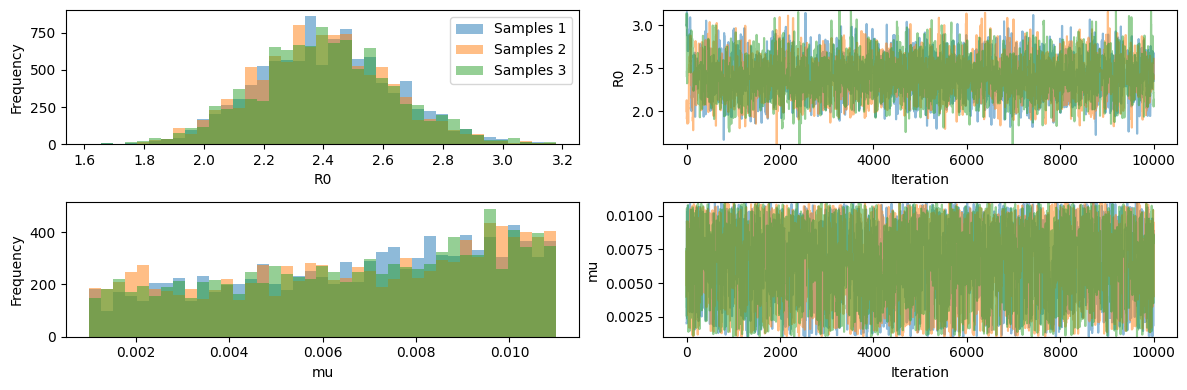

[1.0019664  1.00198805]


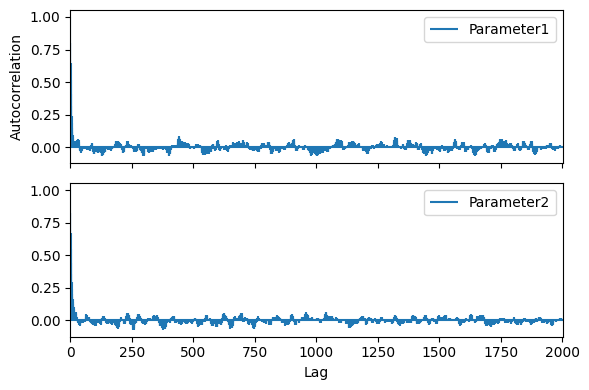

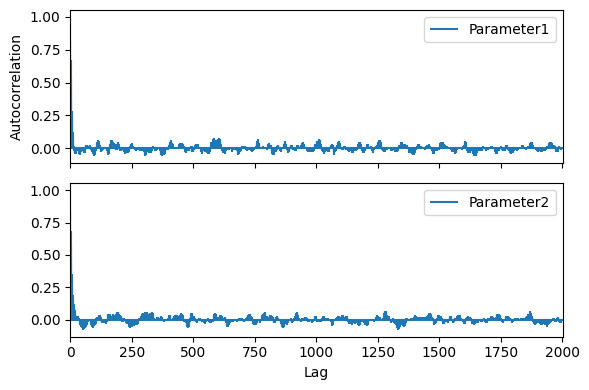

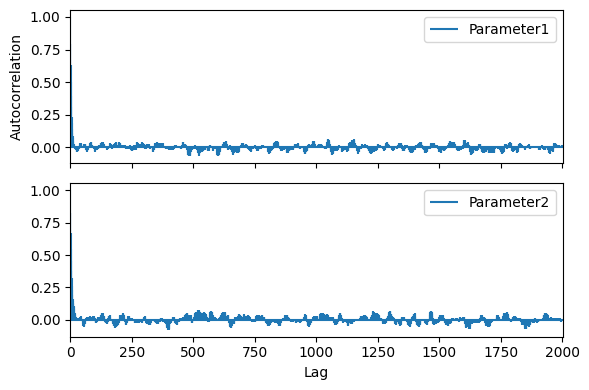

In [17]:
sampling_routine_run(freq_samplying_range[2], sample_size_range[0])

Running...
Using Haario-Bardenet adaptive covariance MCMC
Generating 3 chains.
Running in parallel with 3 worker processess.


/var/folders/ph/jyxnc9y52svgq2k5lt2q4r000000gp/T/ipykernel_55485/3053646109.py:143: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.

/var/folders/ph/jyxnc9y52svgq2k5lt2q4r000000gp/T/ipykernel_55485/3053646109.py:159: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.



Iter. Eval. Accept.   Accept.   Accept.   Time    
0     3      0         0         0          0:03.0
1     6      0         0.5       0          0:03.8
2     9      0         0.333     0          0:03.9
3     12     0         0.5       0          0:04.6
20    63     0.238     0.333     0.286      0:17.7
40    123    0.293     0.366     0.268      0:32.2
60    183    0.295082  0.311     0.213      0:48.7
80    243    0.358     0.296     0.222      1:06.1
100   303    0.376     0.287     0.287      1:24.6
120   363    0.347     0.306     0.289      1:42.7
140   423    0.369     0.312     0.284      2:00.1
160   483    0.373     0.298     0.292      2:17.6
180   543    0.381     0.304     0.293      2:35.0
Initial phase completed.
200   603    0.388     0.303     0.303      2:52.3
220   663    0.403     0.335     0.33       3:10.3
240   723    0.411     0.349     0.340249   3:28.4
260   783    0.391     0.337     0.33       3:44.7
280   843    0.391     0.335     0.335      3:59.8
300   

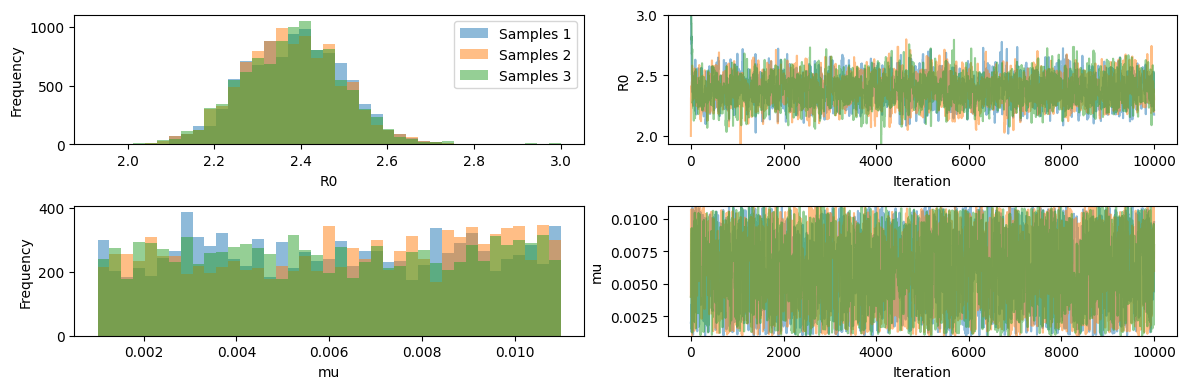

[1.00199233 1.00165425]


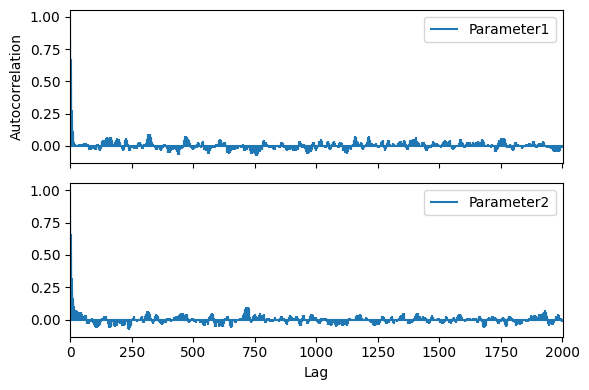

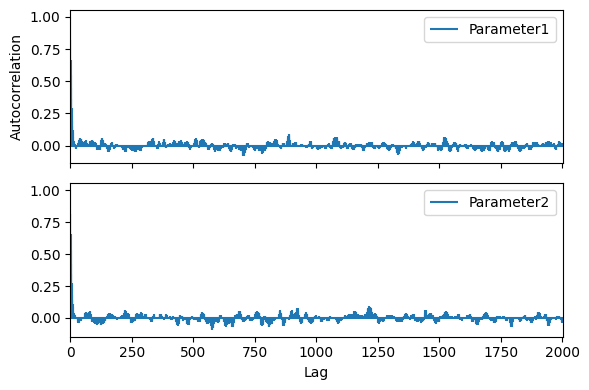

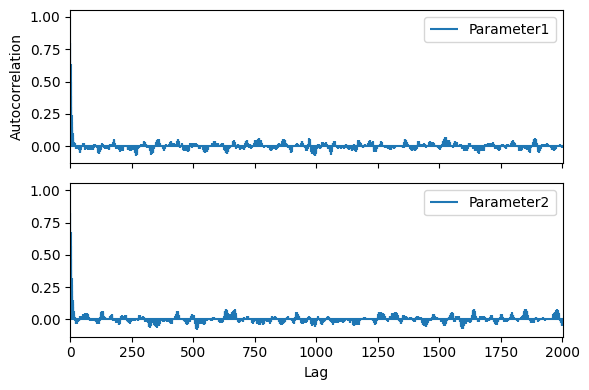

In [17]:
sampling_routine_run(freq_samplying_range[2], sample_size_range[3])

Running...
Using Haario-Bardenet adaptive covariance MCMC
Generating 3 chains.
Running in parallel with 3 worker processess.


/var/folders/ph/jyxnc9y52svgq2k5lt2q4r000000gp/T/ipykernel_60271/3053646109.py:143: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.

/var/folders/ph/jyxnc9y52svgq2k5lt2q4r000000gp/T/ipykernel_60271/3053646109.py:159: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.



Iter. Eval. Accept.   Accept.   Accept.   Time    
0     3      0         0         0          0:01.7
1     6      0.5       0         0          0:01.8
2     9      0.667     0.333     0          0:01.9
3     12     0.75      0.25      0.25       0:01.9
20    63     0.381     0.333     0.524      0:03.1
40    123    0.439     0.317     0.463      0:04.5
60    183    0.426     0.295082  0.442623   0:05.6
80    243    0.469     0.345679  0.432      0:07.0
100   303    0.485     0.356     0.446      0:08.2
120   363    0.512     0.388     0.496      0:09.6
140   423    0.518     0.376     0.504      0:11.0
160   483    0.528     0.398     0.497      0:12.5
180   543    0.541     0.42      0.486      0:14.0
Initial phase completed.
200   603    0.532     0.428     0.478      0:15.4
220   663    0.534     0.438914  0.493      0:17.0
240   723    0.51      0.432     0.481      0:18.3
260   783    0.494     0.425     0.452      0:19.4
280   843    0.473     0.402     0.445      0:20.8
300   

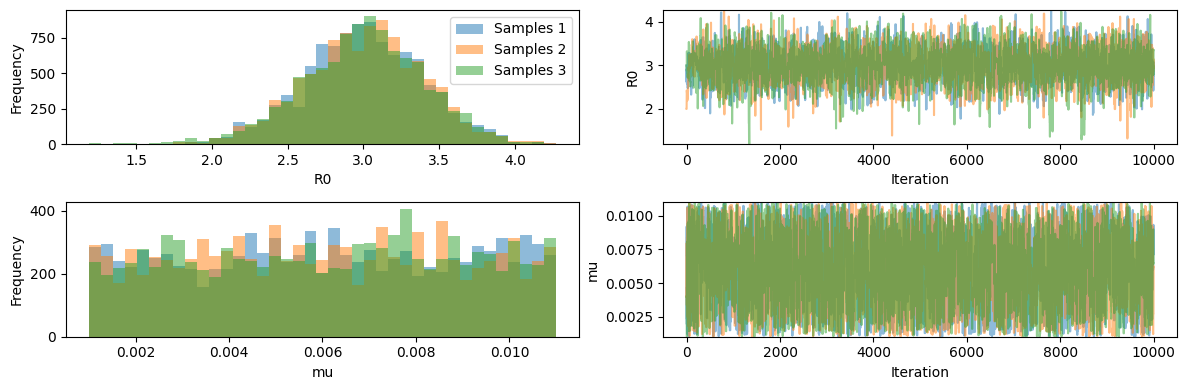

[1.00098299 1.00149636]


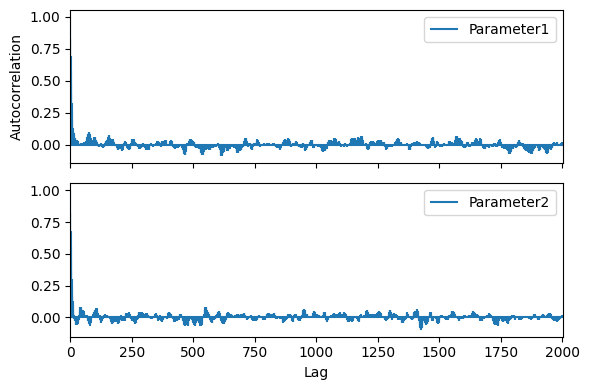

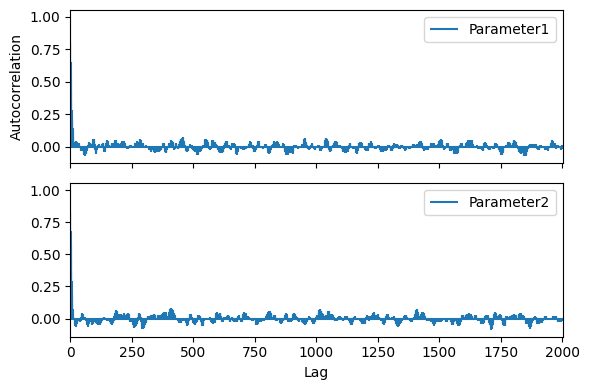

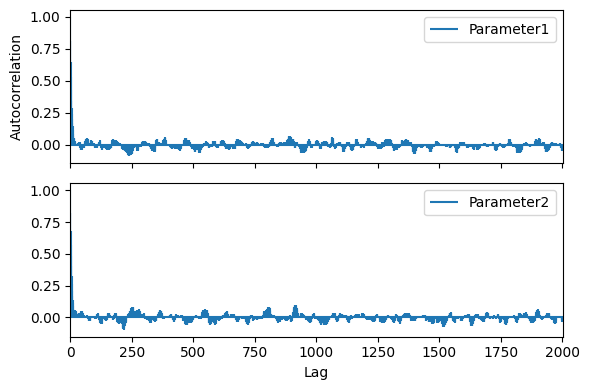

In [17]:
sampling_routine_run(freq_samplying_range[5], sample_size_range[0])

Running...
Using Haario-Bardenet adaptive covariance MCMC
Generating 3 chains.
Running in parallel with 3 worker processess.


/var/folders/ph/jyxnc9y52svgq2k5lt2q4r000000gp/T/ipykernel_61741/3053646109.py:143: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.

/var/folders/ph/jyxnc9y52svgq2k5lt2q4r000000gp/T/ipykernel_61741/3053646109.py:159: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.



Iter. Eval. Accept.   Accept.   Accept.   Time    
0     3      0         0         0          0:02.0
1     6      0         0         0          0:02.0
2     9      0.333     0         0.333      0:02.2
3     12     0.25      0         0.25       0:02.2
20    63     0.476     0.286     0.333      0:05.9
40    123    0.561     0.366     0.366      0:09.7
60    183    0.557377  0.41      0.344      0:13.8
80    243    0.568     0.469     0.308642   0:18.4
100   303    0.584     0.465     0.356      0:22.8
120   363    0.562     0.438     0.364      0:27.1
140   423    0.56      0.468     0.376      0:31.3
160   483    0.565     0.466     0.391      0:34.8
180   543    0.558011  0.464     0.398      0:38.4
Initial phase completed.
200   603    0.547     0.488     0.403      0:42.2
220   663    0.552     0.493     0.421      0:47.1
240   723    0.526971  0.494     0.423      0:50.9
260   783    0.517     0.467433  0.402      0:54.4
280   843    0.488     0.459     0.384      0:57.6
300   

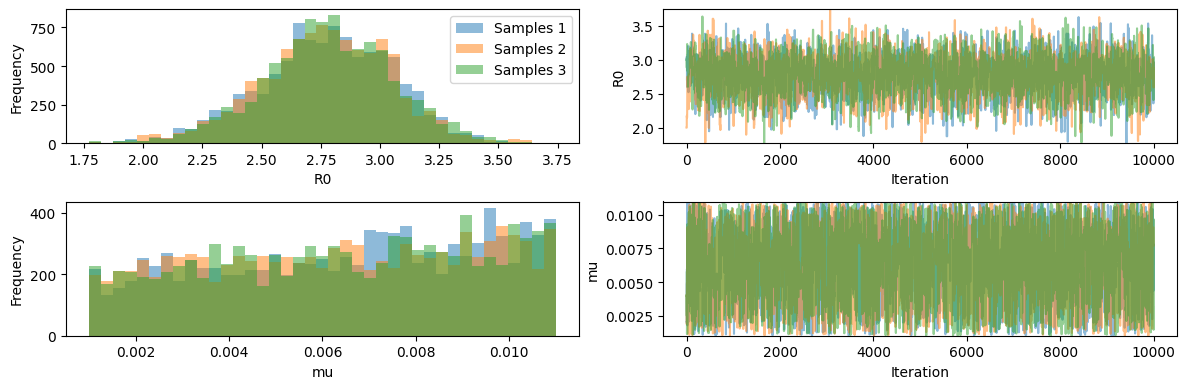

[1.0009443  1.00019354]


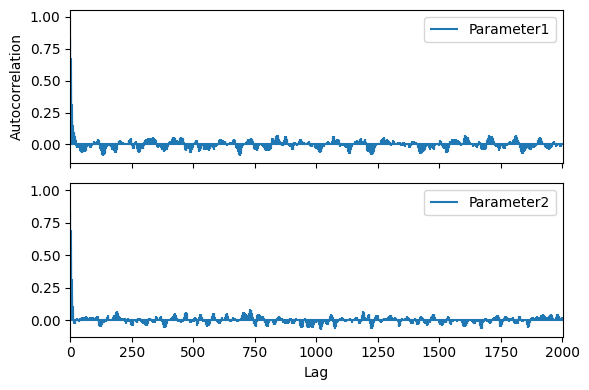

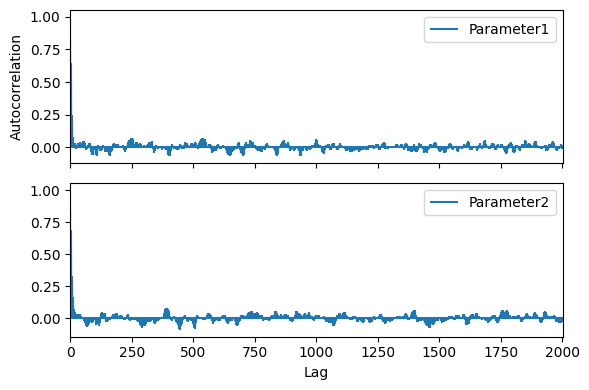

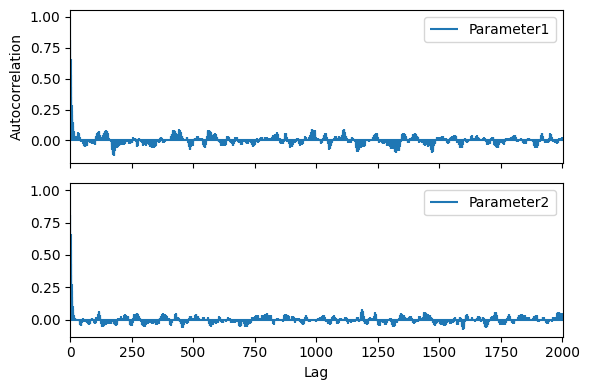

In [17]:
sampling_routine_run(freq_samplying_range[5], sample_size_range[3])